# Notebook 01: Dataset Exploration and XGBoost Baseline

This notebook loads the **TabFormer** (IBM) credit card transaction dataset (~24M transactions), creates temporal train/val/test splits, and trains a GPU-accelerated **XGBoost baseline** for fraud detection.

**Primary metric**: Average Precision (AUPRC) -- more informative than AUROC at realistic fraud rates (~0.1%).

## Outline

0. Setup and Imports
1. Load Raw TabFormer Dataset
2. Temporal Split
3. Data Visualization
4. Preprocessing and Feature Engineering
5. Create Training and Evaluation Datasets
6. XGBoost Baseline
7. Conclusion

---

## Prerequisites: Get the TabFormer Dataset

This notebook requires the [IBM TabFormer](https://github.com/IBM/TabFormer) credit-card transaction dataset (`card_transaction.v1.csv`, ~2.2 GB, ~24M synthetic credit-card transactions).

**Run the cell below** to create the required directory, download `transactions.tgz` from [IBM Box](https://ibm.ent.box.com/v/tabformer-data/folder/130747715605), and extract the CSV to the expected path:

```
data/
└── TabFormer/
    └── raw/
        └── card_transaction.v1.csv
```

> **Note:** If the download fails, retry the cell once. If it still fails, download `transactions.tgz` manually from the IBM Box link above and place it at `data/TabFormer/transactions.tgz`, then re-run the cell.

In [1]:
import tarfile
from pathlib import Path
from urllib.request import urlretrieve

DATA_DIR = Path("data/TabFormer/raw")
TGZ_PATH = DATA_DIR.parent / "transactions.tgz"
CSV_PATH = DATA_DIR / "card_transaction.v1.csv"
DOWNLOAD_URL = (
    "https://ibm.ent.box.com/index.php"
    "?rm=box_download_shared_file"
    "&shared_name=mhrtz6xiknblqznoi9h4f390scoqustt"
    "&file_id=f_770766751708"
)

DATA_DIR.mkdir(parents=True, exist_ok=True)

if not TGZ_PATH.exists():
    print("Downloading transactions.tgz from IBM Box...")
    urlretrieve(DOWNLOAD_URL, TGZ_PATH)

if not CSV_PATH.exists():
    print("Extracting transactions.tgz...")
    with tarfile.open(TGZ_PATH, "r:gz") as tar:
        tar.extractall(path=DATA_DIR)

print(f"Dataset ready: {CSV_PATH.resolve()}")

Dataset already present:
  /workspace/transaction-foundation-model/data/TabFormer/raw/card_transaction.v1.csv


---

## 0. Setup and Imports

In [2]:
%pip install -q "xgboost>=3.0" scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import time
import random
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import cudf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.metrics import roc_auc_score, average_precision_score

import xgboost as xgb
import torch

print(f"cuDF version:    {cudf.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"GPU available:   {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU 0:           {props.name}, {props.total_memory / 1e9:.1f} GB")

XGB_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

cuDF version:    25.04.00
XGBoost version: 3.2.0
GPU available:   True
GPU 0:           NVIDIA H100, 102.1 GB


In [4]:
PROJECT_ROOT = Path(".").resolve()
RAW_CSV = PROJECT_ROOT / "data" / "TabFormer" / "raw" / "card_transaction.v1.csv"
TEMPORAL_SPLIT_DIR = PROJECT_ROOT / "data" / "TabFormer" / "temporal_split"
assert RAW_CSV.exists(), f"Raw CSV not found: {RAW_CSV}"

FEATURE_COLS = [
    'User', 'Card', 'Year', 'Month', 'Day', 'Hour', 'Amount',
    'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State',
    'Zip', 'MCC'
]

EVAL_SAMPLES = 100_000
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print(f"Raw CSV:    {RAW_CSV}")
print(f"Features:   {len(FEATURE_COLS)}d -- {FEATURE_COLS}")

Raw CSV:    /workspace/transaction-foundation-model/data/TabFormer/raw/card_transaction.v1.csv
Features:   13d -- ['User', 'Card', 'Year', 'Month', 'Day', 'Hour', 'Amount', 'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC']


---

## 1. Load Raw TabFormer Dataset

The [TabFormer](https://github.com/IBM/TabFormer) dataset contains ~24.4M synthetic credit card transactions across 2,000 users (10 cards each), spanning 2002--2019, with a ~0.12% fraud rate. We load with RAPIDS cuDF for GPU-accelerated parsing.

In [5]:
print("Loading raw TabFormer dataset with cuDF (GPU)...")
t0 = time.time()
raw_gdf = cudf.read_csv(str(RAW_CSV))
cudf_load_time = time.time() - t0
print(f"cuDF load time: {cudf_load_time:.2f}s")
print(f"Shape: {raw_gdf.shape[0]:,} rows x {raw_gdf.shape[1]} columns")
print(f"Columns: {list(raw_gdf.columns)}")

raw_gdf.head(3).to_pandas()

Loading raw TabFormer dataset with cuDF (GPU)...
cuDF load time: 0.76s
Shape: 24,386,900 rows x 15 columns
Columns: ['User', 'Card', 'Year', 'Month', 'Day', 'Time', 'Amount', 'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC', 'Errors?', 'Is Fraud?']


,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,None,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,None,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,None,No


In [6]:
print("Dataset Summary:")
print(f"  Rows:    {len(raw_gdf):,}")
print(f"  Columns: {raw_gdf.shape[1]}")
print(f"  Users:   {raw_gdf['User'].nunique():,}")

fraud_counts = raw_gdf['Is Fraud?'].value_counts().to_pandas()
total_fraud = int(fraud_counts.get('Yes', 0))
fraud_rate = total_fraud / len(raw_gdf)
print(f"  Fraud:   {total_fraud:,} / {len(raw_gdf):,} ({fraud_rate:.4%})")

years = raw_gdf['Year'].to_pandas()
print(f"  Years:   {years.min()} to {years.max()}")

Dataset Summary:
  Rows:    24,386,900
  Columns: 15
  Users:   2,000
  Fraud:   29,757 / 24,386,900 (0.1220%)
  Years:   1991 to 2020


---

## 2. Temporal Split

We create an 80/10/10 temporal split based on cumulative transaction counts. This ensures the test set contains the most recent transactions, preventing data leakage.

In [7]:
raw_gdf.columns = [c.strip() for c in raw_gdf.columns]

print("Creating date column for temporal splitting...")
t0 = time.time()
year_str = raw_gdf['Year'].astype(str)
month_str = raw_gdf['Month'].astype(str).str.zfill(2)
day_str = raw_gdf['Day'].astype(str).str.zfill(2)
date_str = year_str + '-' + month_str + '-' + day_str
raw_gdf['date'] = cudf.to_datetime(date_str, format='%Y-%m-%d')
cudf_date_time = time.time() - t0
print(f"cuDF date creation: {cudf_date_time:.2f}s")

Creating date column for temporal splitting...
cuDF date creation: 0.08s


In [8]:
def find_cutoff_date(gdf, target_ratio):
    """Find date where cumulative row count reaches target_ratio of total."""
    daily_counts = gdf.groupby('date').size().reset_index(name='count')
    daily_counts = daily_counts.sort_values('date')
    daily_counts['cumulative'] = daily_counts['count'].cumsum()
    total = int(daily_counts['cumulative'].iloc[-1])
    target = total * target_ratio
    cutoff_pdf = daily_counts[daily_counts['cumulative'] >= target].head(1).to_pandas()
    return cutoff_pdf['date'].iloc[0]

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1

train_cutoff = find_cutoff_date(raw_gdf, TRAIN_RATIO)
test_cutoff = find_cutoff_date(raw_gdf, TRAIN_RATIO + VAL_RATIO)

print(f"Train/Val cutoff: {train_cutoff.strftime('%Y-%m-%d')}")
print(f"Val/Test cutoff:  {test_cutoff.strftime('%Y-%m-%d')}")

Train/Val cutoff: 2017-05-14
Val/Test cutoff:  2018-10-12


In [9]:
train_mask = raw_gdf['date'] < np.datetime64(train_cutoff)
val_mask = (raw_gdf['date'] >= np.datetime64(train_cutoff)) & (raw_gdf['date'] < np.datetime64(test_cutoff))
test_mask = raw_gdf['date'] >= np.datetime64(test_cutoff)

train_gdf = raw_gdf[train_mask].drop(columns=['date']).reset_index(drop=True)
val_gdf = raw_gdf[val_mask].drop(columns=['date']).reset_index(drop=True)
test_gdf = raw_gdf[test_mask].drop(columns=['date']).reset_index(drop=True)

del raw_gdf

def split_stats(gdf):
    n = len(gdf)
    fraud = int((gdf['Is Fraud?'].str.lower() == 'yes').sum())
    return n, fraud, fraud / n * 100

total = len(train_gdf) + len(val_gdf) + len(test_gdf)
print(f"{'Split':<8} {'Rows':>12} {'%':>7} {'Fraud':>8} {'Fraud Rate':>12}")
print("-" * 52)
for name, gdf in [('Train', train_gdf), ('Val', val_gdf), ('Test', test_gdf)]:
    n, fraud, rate = split_stats(gdf)
    print(f"{name:<8} {n:>12,} {n/total*100:>6.2f}% {fraud:>8,} {rate:>11.4f}%")
print("-" * 52)
print(f"{'Total':<8} {total:>12,}")

Split            Rows       %    Fraud   Fraud Rate
----------------------------------------------------
Train      19,508,123  79.99%   24,924      0.1278%
Val         2,435,982   9.99%    2,109      0.0866%
Test        2,442,795  10.02%    2,724      0.1115%
----------------------------------------------------
Total      24,386,900


In [10]:
TEMPORAL_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

t0 = time.time()
for name, gdf in [("train", train_gdf), ("val", val_gdf), ("test", test_gdf)]:
    path = TEMPORAL_SPLIT_DIR / f"{name}.parquet"
    gdf.to_parquet(str(path), index=False)
    print(f"Saved: {path} ({len(gdf):,} rows)")
parquet_time = time.time() - t0
print(f"\nParquet write time: {parquet_time:.2f}s")
print(f"Temporal splits saved for reuse by downstream notebooks.")

Saved: /workspace/transaction-foundation-model/data/TabFormer/temporal_split/train.parquet (19,508,123 rows)
Saved: /workspace/transaction-foundation-model/data/TabFormer/temporal_split/val.parquet (2,435,982 rows)
Saved: /workspace/transaction-foundation-model/data/TabFormer/temporal_split/test.parquet (2,442,795 rows)

Parquet write time: 0.69s
Temporal splits saved for reuse by downstream notebooks.


---

## 3. Data Visualization

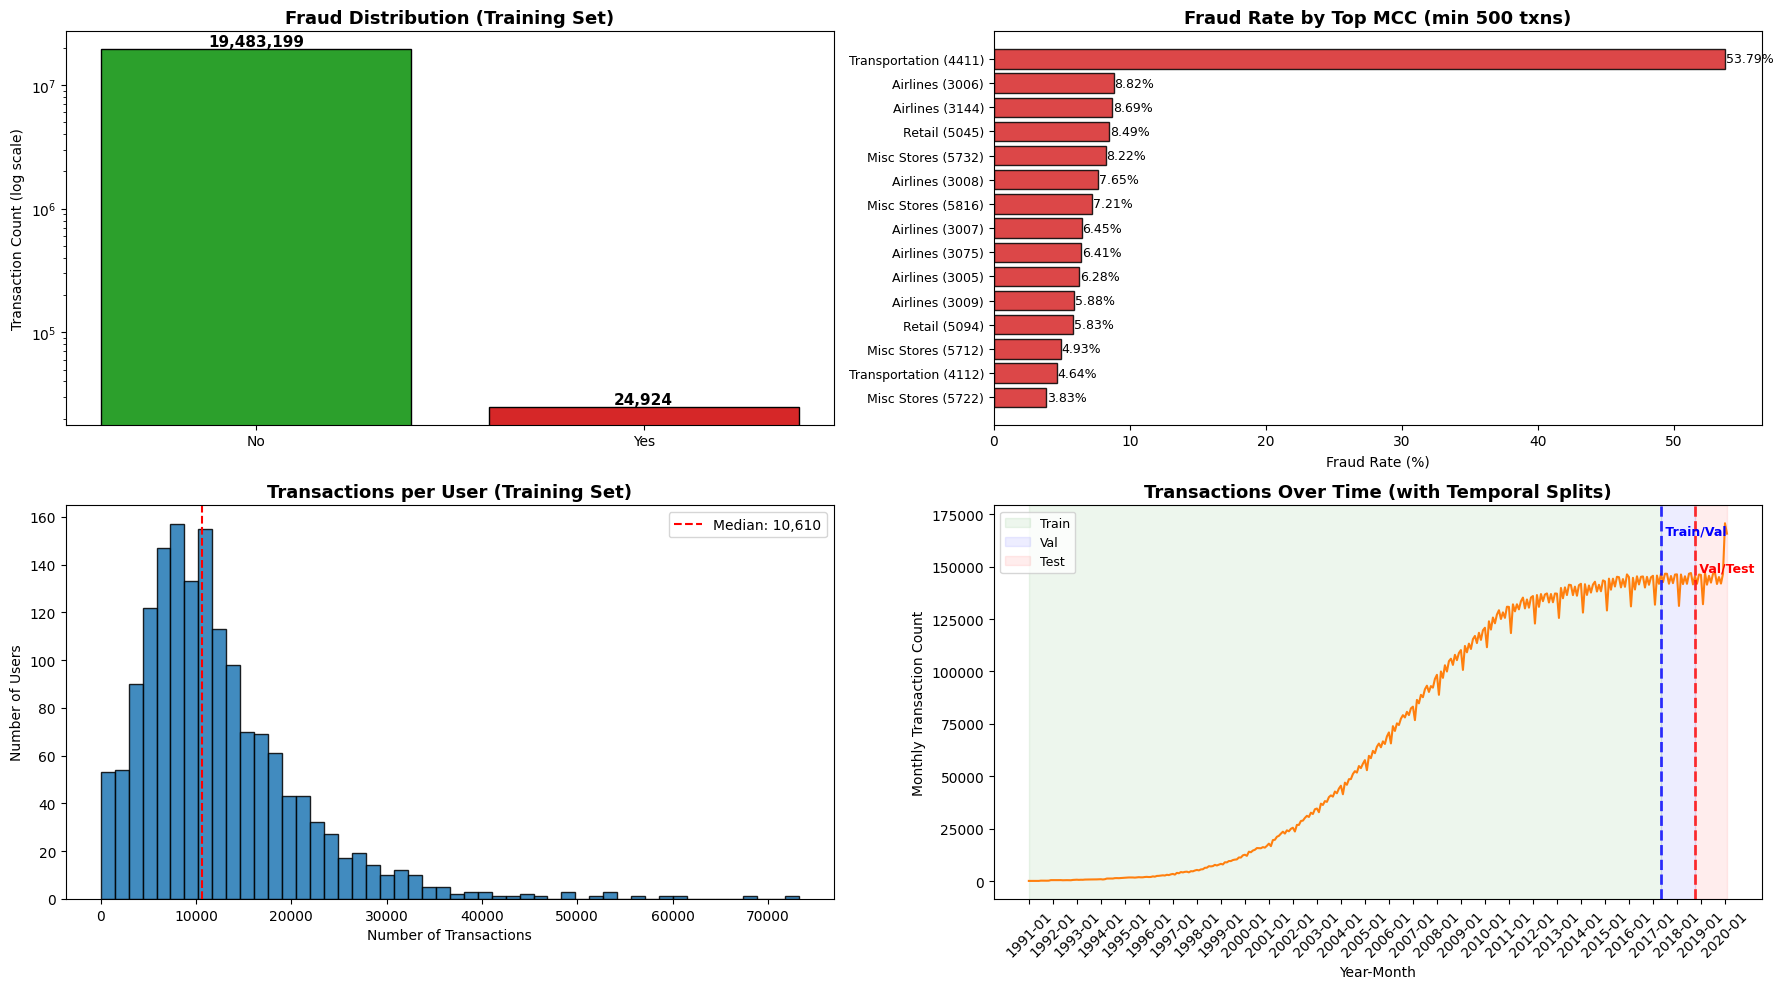

In [11]:
all_gdf = cudf.concat([train_gdf, val_gdf, test_gdf], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# 1. Fraud Distribution (extreme imbalance)
ax1 = axes[0, 0]
fraud_counts_pd = train_gdf['Is Fraud?'].value_counts().to_pandas()
colors = ['#2ca02c', '#d62728']
bars = ax1.bar(fraud_counts_pd.index, fraud_counts_pd.values, color=colors, edgecolor='black')
ax1.set_title('Fraud Distribution (Training Set)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, fraud_counts_pd.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_yscale('log')
ax1.set_ylabel('Transaction Count (log scale)')

# 2. Transactions per User (important for sequential modeling in Section 2)
ax2 = axes[1, 0]
txn_per_user = train_gdf.groupby('User')['User'].count().values_host
ax2.hist(txn_per_user, bins=50, color='#1f77b4', edgecolor='black', alpha=0.85)
ax2.set_title('Transactions per User (Training Set)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Transactions')
ax2.set_ylabel('Number of Users')
ax2.axvline(x=int(cudf.Series(txn_per_user).median()), color='red', linestyle='--',
            linewidth=1.5, label=f'Median: {int(cudf.Series(txn_per_user).median()):,}')
ax2.legend(fontsize=10)

# 3. Transactions Over Time with temporal split boundaries
ax3 = axes[1, 1]
all_gdf['_year'] = all_gdf['Year'].astype(int)
all_gdf['_month'] = all_gdf['Month'].astype(int)
monthly = all_gdf.groupby(['_year', '_month']).size().reset_index(name='count')
monthly['period'] = monthly['_year'].astype(str) + '-' + monthly['_month'].astype(str).str.zfill(2)
monthly = monthly.sort_values('period').reset_index(drop=True).to_pandas()

ax3.plot(range(len(monthly)), monthly['count'].values, color='#ff7f0e', linewidth=1.5)

train_cutoff_period = f"{train_cutoff.year}-{train_cutoff.month:02d}"
test_cutoff_period = f"{test_cutoff.year}-{test_cutoff.month:02d}"

tc_idx = monthly.index[monthly['period'] == train_cutoff_period]
vc_idx = monthly.index[monthly['period'] == test_cutoff_period]
tc_x = tc_idx[0] if len(tc_idx) > 0 else None
vc_x = vc_idx[0] if len(vc_idx) > 0 else None

if tc_x is not None:
    ax3.axvline(x=tc_x, color='blue', linestyle='--', linewidth=2, alpha=0.8)
    ax3.text(tc_x, ax3.get_ylim()[1] * 0.95, ' Train/Val', color='blue',
             fontsize=9, fontweight='bold', va='top')
if vc_x is not None:
    ax3.axvline(x=vc_x, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax3.text(vc_x, ax3.get_ylim()[1] * 0.85, ' Val/Test', color='red',
             fontsize=9, fontweight='bold', va='top')

if tc_x is not None and vc_x is not None:
    ax3.axvspan(0, tc_x, alpha=0.07, color='green', label='Train')
    ax3.axvspan(tc_x, vc_x, alpha=0.07, color='blue', label='Val')
    ax3.axvspan(vc_x, len(monthly)-1, alpha=0.07, color='red', label='Test')
    ax3.legend(loc='upper left', fontsize=9)

tick_positions = range(0, len(monthly), 12)
tick_labels = [monthly['period'].iloc[i] for i in tick_positions]
ax3.set_xticks(list(tick_positions))
ax3.set_xticklabels(tick_labels, rotation=45)
ax3.set_title('Transactions Over Time (with Temporal Splits)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Monthly Transaction Count')
ax3.set_xlabel('Year-Month')

# 4. Fraud Rate by Top Merchant Categories (MCC)
ax4 = axes[0, 1]

MCC_INDUSTRY_RANGES = [
    (0, 1499, "Agricultural"), (1500, 2999, "Contracted"),
    (3000, 3299, "Airlines"), (3300, 3499, "Car Rental"),
    (3500, 3999, "Lodging"), (4000, 4799, "Transportation"),
    (4800, 4999, "Utilities"), (5000, 5599, "Retail"),
    (5600, 5699, "Clothing"), (5700, 7299, "Misc Stores"),
    (7300, 7999, "Business Services"), (8000, 8999, "Professional"),
    (9000, 9999, "Government"),
]
def mcc_label(code):
    code = int(code)
    for lo, hi, name in MCC_INDUSTRY_RANGES:
        if lo <= code <= hi:
            return f"{name} ({code})"
    return str(code)

_fraud_flag = (train_gdf['Is Fraud?'].str.lower() == 'yes').astype('int32')
mcc_fraud_sum = _fraud_flag.groupby(train_gdf['MCC']).sum()
mcc_total = _fraud_flag.groupby(train_gdf['MCC']).count()
mcc_fraud_rate = (mcc_fraud_sum / mcc_total * 100)

min_txns = 500
mask = mcc_total >= min_txns
mcc_fraud_rate_filtered = mcc_fraud_rate[mask].sort_values(ascending=False)
top_mccs = mcc_fraud_rate_filtered.head(15)

mcc_codes = top_mccs.index.values_host
rates = top_mccs.values_host
labels = [mcc_label(c) for c in mcc_codes]
bar_colors = ['#d62728' if r > 1.0 else '#ff7f0e' for r in rates]
bars = ax4.barh(range(len(labels)), rates, color=bar_colors, edgecolor='black', alpha=0.85)
ax4.set_yticks(range(len(labels)))
ax4.set_yticklabels(labels, fontsize=9)
ax4.invert_yaxis()
ax4.set_xlabel('Fraud Rate (%)')
ax4.set_title(f'Fraud Rate by Top MCC (min {min_txns} txns)', fontsize=13, fontweight='bold')
for bar, rate in zip(bars, rates):
    ax4.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{rate:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

del all_gdf

---

## 4. Preprocessing and Feature Engineering

Clean the `Amount` field (strip `$` and `,`), extract `Hour` from the `Time` column, and encode the fraud target as binary.

In [12]:
print("Feature engineering with cuDF (GPU)...")
t0 = time.time()
for gdf in [train_gdf, val_gdf, test_gdf]:
    gdf['Hour'] = gdf['Time'].str.split(':', n=1, expand=True)[0].astype(int)
    gdf['Amount'] = gdf['Amount'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)
    gdf['_target'] = ((gdf['Is Fraud?'] == 'Yes') | (gdf['Is Fraud?'] == '1')).astype(int)
cudf_fe_time = time.time() - t0
print(f"cuDF feature engineering: {cudf_fe_time:.2f}s")

Feature engineering with cuDF (GPU)...
cuDF feature engineering: 0.05s


In [13]:
print("Converting to pandas for downstream modeling...")
t0 = time.time()
train_df = train_gdf.to_pandas()
val_df = val_gdf.to_pandas()
test_df = test_gdf.to_pandas()
convert_time = time.time() - t0
print(f"cuDF -> pandas conversion: {convert_time:.2f}s")

del train_gdf, val_gdf, test_gdf

print(f"\n13-dimensional feature set:")
for i, col in enumerate(FEATURE_COLS):
    dtype = train_df[col].dtype
    nunique = train_df[col].nunique()
    print(f"  {i+1:2d}. {col:<20s} dtype={str(dtype):<10s} unique={nunique:,}")

print(f"\nTarget distribution:")
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"  {name}: {df['_target'].sum():,} fraud / {len(df):,} total ({df['_target'].mean():.4%})")

print(f"\nSample preprocessed row:")
train_df[FEATURE_COLS + ['_target']].head(3)

Converting to pandas for downstream modeling...
cuDF -> pandas conversion: 8.33s

13-dimensional feature set:
   1. User                 dtype=int64      unique=1,584
   2. Card                 dtype=int64      unique=9
   3. Year                 dtype=int64      unique=27
   4. Month                dtype=int64      unique=12
   5. Day                  dtype=int64      unique=31
   6. Hour                 dtype=int64      unique=24
   7. Amount               dtype=float64    unique=92,592
   8. Use Chip             dtype=object     unique=3
   9. Merchant Name        dtype=int64      unique=91,265
  10. Merchant City        dtype=object     unique=13,149
  11. Merchant State       dtype=object     unique=217
  12. Zip                  dtype=float64    unique=26,680
  13. MCC                  dtype=int64      unique=109

Target distribution:
  Train: 24,924 fraud / 19,508,123 total (0.1278%)
  Val: 2,109 fraud / 2,435,982 total (0.0866%)
  Test: 2,724 fraud / 2,442,795 total (0.1115%)



,User,Card,Year,Month,Day,Hour,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,_target
0,0,0,2002,9,1,6,134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,0
1,0,0,2002,9,1,6,38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,0
2,0,0,2002,9,2,6,120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,0


---

## 5. Create Training and Evaluation Datasets

We create a **1M balanced training set** for the XGBoost baseline (all fraud transactions plus sampled normal transactions) and **100k stratified evaluation subsets** for validation and test. The full temporal splits remain saved and are still used by later notebooks for sequence modeling and foundation model training.


In [14]:
from sklearn.model_selection import train_test_split

BALANCED_TRAIN_SIZE = 1_000_000


def create_balanced_train_sample(df, feature_cols, target_col='_target', total_samples=1_000_000, random_state=42):
    """Create balanced training sample: all fraud + sampled normal."""
    np.random.seed(random_state)
    fraud_idx = df.index[df[target_col] == 1].tolist()
    normal_idx = df.index[df[target_col] == 0].tolist()

    n_fraud = min(len(fraud_idx), int(total_samples * 0.1))
    n_normal = min(len(normal_idx), total_samples - n_fraud)

    sampled_fraud = np.random.choice(fraud_idx, n_fraud, replace=False)
    sampled_normal = np.random.choice(normal_idx, n_normal, replace=False)
    sampled_idx = np.concatenate([sampled_fraud, sampled_normal])
    np.random.shuffle(sampled_idx)

    sampled_df = df.loc[sampled_idx]
    X = sampled_df[feature_cols].reset_index(drop=True)
    y = sampled_df[target_col].values
    return X, y


def stratified_subsample(df, feature_cols, target_col, n_samples, random_state=42):
    """Stratified subsample preserving the original class distribution."""
    if n_samples >= len(df):
        X_sub = df[feature_cols]
        y_sub = df[target_col]
    else:
        _, X_sub, _, y_sub = train_test_split(
            df[feature_cols], df[target_col],
            test_size=n_samples, stratify=df[target_col], random_state=random_state
        )
    return X_sub, y_sub.values


print(f"Creating {BALANCED_TRAIN_SIZE:,} balanced training sample (all fraud + sampled normal)...")
X_train_1m, y_train_1m = create_balanced_train_sample(
    train_df,
    FEATURE_COLS,
    total_samples=BALANCED_TRAIN_SIZE,
    random_state=RANDOM_STATE,
)
print(f"  Train: {X_train_1m.shape}, Fraud: {y_train_1m.sum():,} ({y_train_1m.mean():.4%})")

print(f"\nCreating {EVAL_SAMPLES:,}-sample stratified eval subsets (preserving fraud rate)...")
X_val, y_val = stratified_subsample(val_df, FEATURE_COLS, '_target', EVAL_SAMPLES, RANDOM_STATE)
X_test, y_test = stratified_subsample(test_df, FEATURE_COLS, '_target', EVAL_SAMPLES, RANDOM_STATE)

print(f"  Val:  {X_val.shape}, Fraud: {y_val.sum():,} ({y_val.mean():.4%})")
print(f"  Test: {X_test.shape}, Fraud: {y_test.sum():,} ({y_test.mean():.4%})")

for split_name, subset_idx in [("val_eval", X_val.index), ("test_eval", X_test.index)]:
    base_split = split_name.split('_')[0]
    raw_full = pd.read_parquet(TEMPORAL_SPLIT_DIR / f"{base_split}.parquet")
    subset_raw = raw_full.iloc[subset_idx].reset_index(drop=True)
    out_path = TEMPORAL_SPLIT_DIR / f"{split_name}.parquet"
    subset_raw.to_parquet(out_path, index=False)
    fraud_vals = subset_raw['Is Fraud?'].astype(str).str.lower().eq('yes')
    print(f"Saved {split_name}: {len(subset_raw):,} rows -> {out_path.name} "
          f"(fraud {fraud_vals.sum():,}, {fraud_vals.mean():.4%})")

print("\nFull train/val/test parquets are unchanged for downstream model training.")
print("Saved val_eval/test_eval parquets for NB04-NB05 faster evaluation workflow.")


Creating 1,000,000 balanced training sample (all fraud + sampled normal)...
  Train: (1000000, 13), Fraud: 24,924 (2.4924%)

Creating 100,000-sample stratified eval subsets (preserving fraud rate)...
  Val:  (100000, 13), Fraud: 87 (0.0870%)
  Test: (100000, 13), Fraud: 112 (0.1120%)
Saved val_eval: 100,000 rows -> val_eval.parquet (fraud 87, 0.0870%)
Saved test_eval: 100,000 rows -> test_eval.parquet (fraud 112, 0.1120%)

Full train/val/test parquets are unchanged for downstream model training.
Saved val_eval/test_eval parquets for NB04-NB05 faster evaluation workflow.


In [15]:
print("Encoding categorical features for XGBoost...")
preprocessor = make_column_transformer(
    (OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
     make_column_selector(dtype_include=['object', 'category'])),
    remainder='passthrough'
)

X_train_1m_enc = preprocessor.fit_transform(X_train_1m)
X_val_enc = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test)

print(f"Encoded shapes:")
print(f"  Train: {X_train_1m_enc.shape}")
print(f"  Val:   {X_val_enc.shape}")
print(f"  Test:  {X_test_enc.shape}")


Encoding categorical features for XGBoost...
Encoded shapes:
  Train: (1000000, 13)
  Val:   (100000, 13)
  Test:  (100000, 13)


---

## 6. XGBoost Baseline (GPU-Accelerated)

We train a GPU-accelerated XGBoost classifier on the **1M balanced** training sample with HPO-optimized hyperparameters, and evaluate on the **100k stratified** validation/test subsets. We report both AUROC and Average Precision (AP) -- at ~0.1% fraud rate, AP is the more operationally meaningful metric since AUROC can be misleadingly high.


In [16]:
XGB_PARAMS_HPO = {
    'n_estimators': 418,
    'max_depth': 8,
    'learning_rate': 0.00229,
    'colsample_bytree': 0.966,
    'min_child_weight': 16,
    'subsample': 0.673,
    'reg_alpha': 0.00387,
    'reg_lambda': 2.77e-08,
    'random_state': RANDOM_STATE,
}

print("Using HPO-tuned parameters for 1M balanced training:")
print(f"  {XGB_PARAMS_HPO}")


def train_xgb(X_train, y_train, X_val, y_val, X_test, y_test, params, name="Model"):
    """Train XGBoost with HPO-tuned params and early stopping."""
    print(f"\nTraining {name}...")
    print(f"  Features: {X_train.shape[1]}d | Samples: {X_train.shape[0]:,}")
    t0 = time.time()
    clf = xgb.XGBClassifier(
        **params,
        scale_pos_weight=1.0,
        tree_method='hist',
        device=XGB_DEVICE,
        early_stopping_rounds=20,
        eval_metric='auc',
    )
    clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    train_time = time.time() - t0

    val_preds = clf.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_preds)
    val_ap = average_precision_score(y_val, val_preds)

    test_preds = clf.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, test_preds)
    test_ap = average_precision_score(y_test, test_preds)

    print(f"  Train time: {train_time:.1f}s (best_iteration={clf.best_iteration})")
    print(f"  Val  ROC-AUC: {val_auc:.4f} | AP: {val_ap:.4f}")
    print(f"  Test ROC-AUC: {test_auc:.4f} | AP: {test_ap:.4f}")

    return clf, {'val_auc': val_auc, 'val_ap': val_ap,
                 'test_auc': test_auc, 'test_ap': test_ap}


Using HPO-tuned parameters for 1M balanced training:
  {'n_estimators': 418, 'max_depth': 8, 'learning_rate': 0.00229, 'colsample_bytree': 0.966, 'min_child_weight': 16, 'subsample': 0.673, 'reg_alpha': 0.00387, 'reg_lambda': 2.77e-08, 'random_state': 42}


In [17]:
clf_baseline, metrics_baseline = train_xgb(
    X_train_1m_enc, y_train_1m,
    X_val_enc, y_val,
    X_test_enc, y_test,
    params=XGB_PARAMS_HPO,
    name="XGBoost Baseline (13d raw features, 1M balanced, HPO)"
)



Training XGBoost Baseline (13d raw features, 1M balanced, HPO)...
  Features: 13d | Samples: 1,000,000
  Train time: 0.6s (best_iteration=3)
  Val  ROC-AUC: 0.9873 | AP: 0.1859
  Test ROC-AUC: 0.9914 | AP: 0.1424


---

## 7. Baseline Reference for NB05

For downstream comparison in notebook 05, use this notebook's XGBoost baseline as the anchor point:

- **Test AUPRC baseline: 0.1424**
- **Test AUROC baseline: 0.9914**

Keep this reference in mind when evaluating embeddings-only and combined raw+embedding models in NB05.

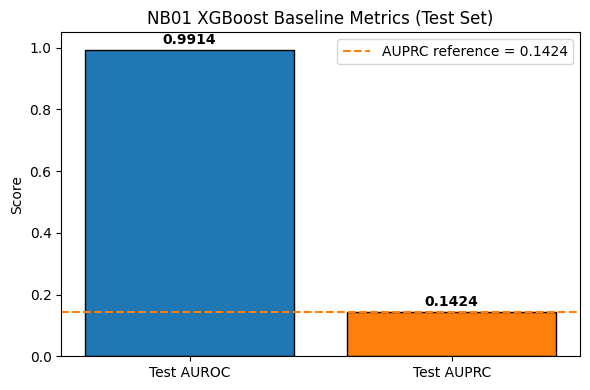

NB05 reference baseline -> Test AUPRC: 0.1424
Current run            -> Test AUPRC: 0.1424 (delta: +0.0000)
Current run            -> Test AUROC: 0.9914


In [18]:
# Compact baseline metric plot for quick NB05 comparison
baseline_auprc_reference = 0.1424

test_auc = metrics_baseline['test_auc']
test_ap = metrics_baseline['test_ap']

fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Test AUROC', 'Test AUPRC']
values = [test_auc, test_ap]
colors = ['#1f77b4', '#ff7f0e']

bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=1)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.4f}",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(baseline_auprc_reference, color='#ff7f0e', linestyle='--', linewidth=1.5,
           label=f"AUPRC reference = {baseline_auprc_reference:.4f}")
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('NB01 XGBoost Baseline Metrics (Test Set)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"NB05 reference baseline -> Test AUPRC: {baseline_auprc_reference:.4f}")
print(f"Current run            -> Test AUPRC: {test_ap:.4f} (delta: {test_ap - baseline_auprc_reference:+.4f})")
print(f"Current run            -> Test AUROC: {test_auc:.4f}")

---

## 8. Conclusion

We established an XGBoost baseline on the TabFormer fraud detection dataset using 13 raw tabular features with a **1M balanced training sample**, **HPO-tuned parameters**, and **100k stratified eval subsets**. While XGBoost achieves strong AUROC, the low Average Precision reflects the difficulty of fraud detection at realistic class imbalance (~0.1% fraud rate).

In the next notebooks, we build a **domain-specific foundation model** that learns sequential transaction patterns via self-supervised pre-training, and show that combining its learned embeddings with raw features significantly improves fraud detection precision.

Continue to [02_seq_preproc_tokenization.ipynb](./02_seq_preproc_tokenization.ipynb).
